# Collin County Property Appraisal Data Extract Transform and Load (ETL)

## Data Source 

### Reference 1: https://www.texas.gov/texas-open-data-portal/  
"In 2019, Texas Senate Bill (SB) 819 required that each State agency prioritize using the Texas Open Data Portal to increase government transparency and data sharing efficiency.  

Data.texas.gov is the State’s Open Data Portal. It features tools to search, filter, map, and visualize official State agency data sets.  
Users can access these data sets to meet their unique information needs for research, collaboration, innovation, and more.

This is the official [Texas] State repository for publicly accessible data!

The license for this dataset is unspecified"  


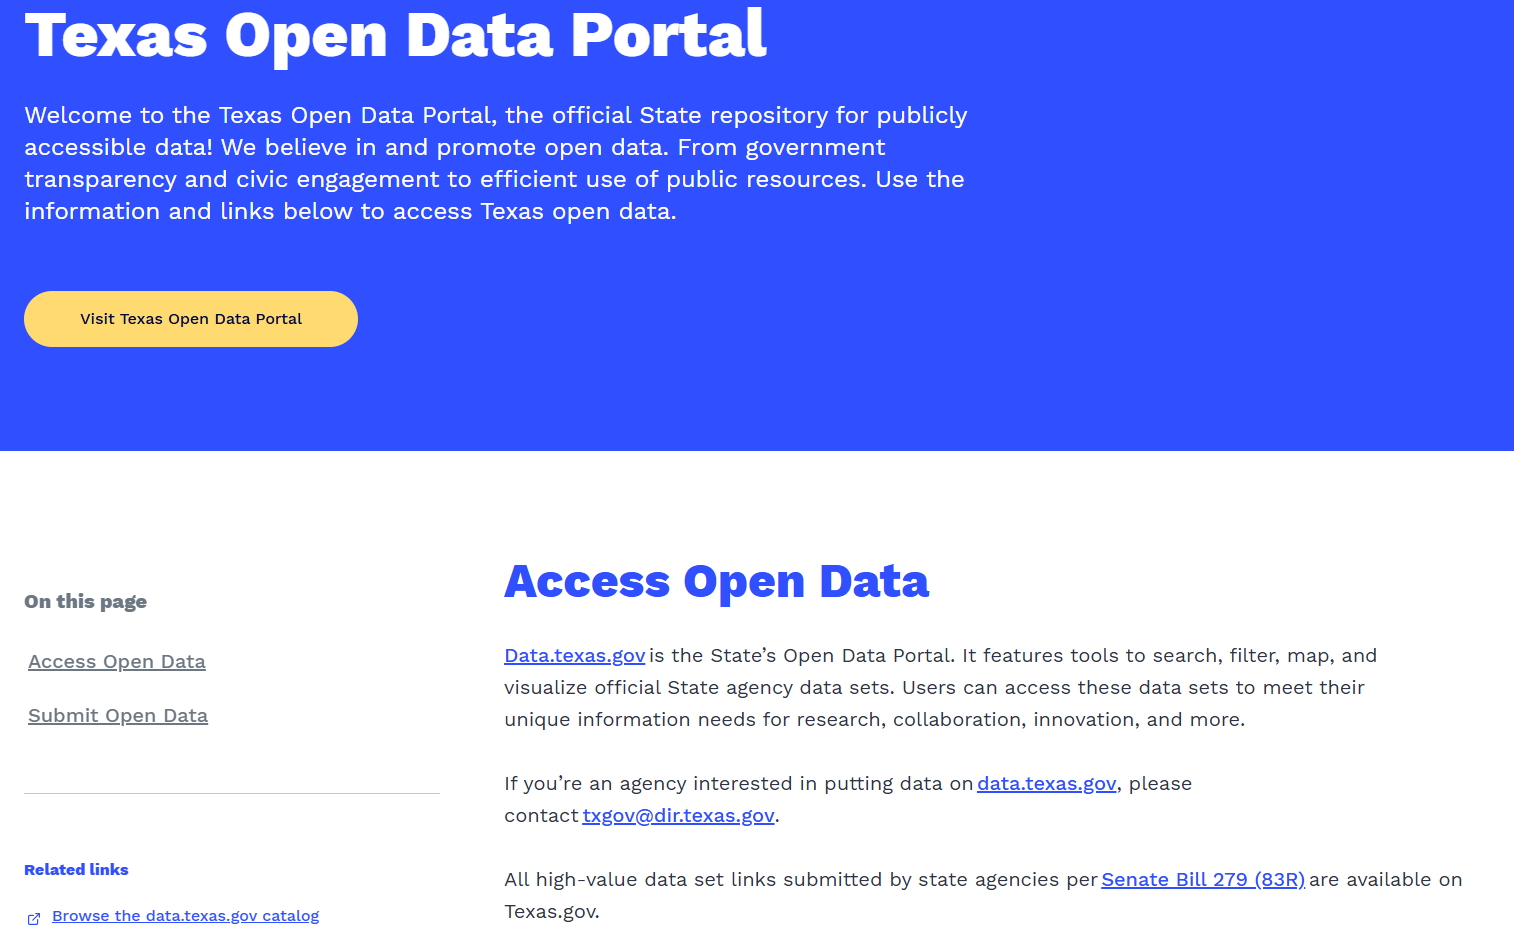

### Reference 2: https://data.texas.gov/stories/s/Welcome-to-the-Texas-Open-Data-Portal-2025/pgq4-7ntc/#:~:text=What%20is%20open%20data?,license%20number%2C%20or%20medical%20information  

"What is open data?
Open data refers to information that can be freely used, re-used, and redistributed by anyone.  
It is readable by a computer so that it can be filtered, sorted, manipulated and downloaded for use.  

As a public resource, open data offers economic, performance, and social value:
* Offers private business a way to better understand potential markets and integrate government data into new, more innovative products and services,
* Increases government transparency and accountability to its citizens, and 
* Improves the quality and efficiency of government services by allowing citizens and policy makers to make more informed data-driven decisions.  
It is important to note that open data does not include Protected Health Information (PHI) or Personally Identifiable Information (PII) that is protected by law, such as a social security number, driver license number, or medical information."

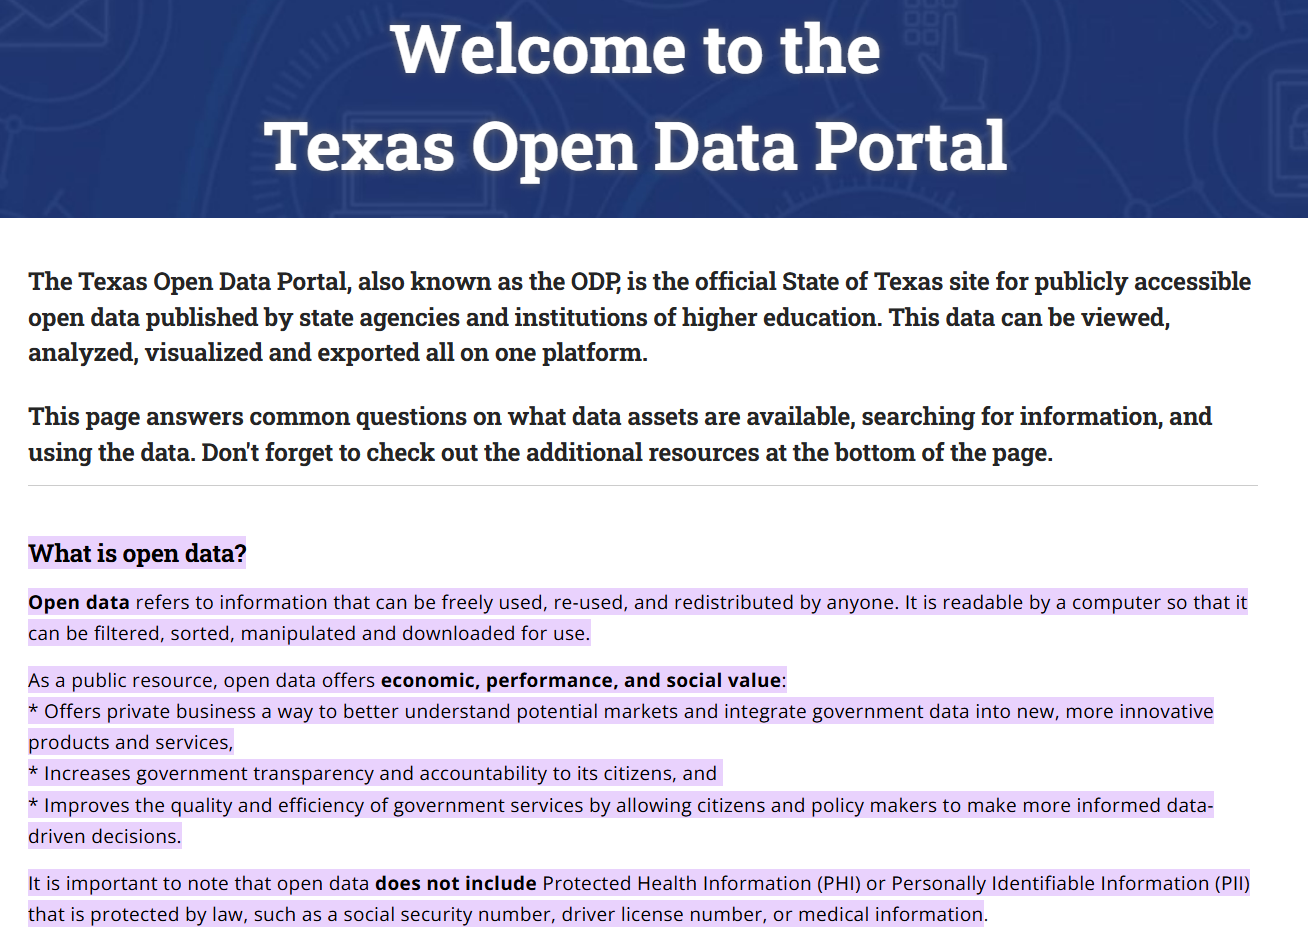


## Disclaimer 

Data Source: This project utilizes open data from the Texas.gov Open Data Portal. While the portal aims to provide non-regulated, public information, I have no control over what is published there.

PII Removal Efforts: The original publicly available dataset may have contained non-sensitive personally identifiable information (PII).  
This project makes a good-faith effort to anonymize or redact such information where possible. However, complete removal is not guaranteed.  

No Liability for Data Changes: I am not responsible for the contents of the upstream dataset.  
If the State of Texas or its agencies add new columns, fields, or records that contain PII or could lead to the identification of an individual, I am not liable for the presence of that data in this project.

No Affiliation or Maintenance: I am not affiliated with the Texas Department of Information Resources (DIR) or any state agency. I do not maintain the official data and provide this project "as is" with no warranty of any kind.

User Responsibility: Users of this project are responsible for complying with the Texas Data Privacy and Security Act and all other applicable privacy laws when handling or redistributing this data.



# What to Expect

### For our project, we are going to:
1. Use an API available on the https://www.texas.gov/texas-open-data-portal/ platform to obtain raw appraisal data for Collin County, Texas.
2. We are going to clean that data and prepare it for public use on the Kaggle platform.


# Lets Begin!

### Our Data
For our review, we are going to be using the Collin County, Texas, appraisal data.  

Navigate over to https://data.texas.gov/dataset/Collin-CAD-Appraisal-Data-Preliminary/nne4-8riu/about_data to check out the landing page for this information.

You will find that this dataset is update daily by Collin County, and is relevant for this year, 2026.  
It has a data dictionary on this page that explains what each data point means.

Link to column decoder here:  
https://data.texas.gov/api/views/nne4-8riu/files/8e7ebe84-fbaf-4608-9064-012aeae3efe4?download=true&filename=Collin%20CAD%20File%20Layout%20-%20Appraisal%20Data.pdf

It also tells us that there are approximately 501,000 rows of data, each of which is a property.  

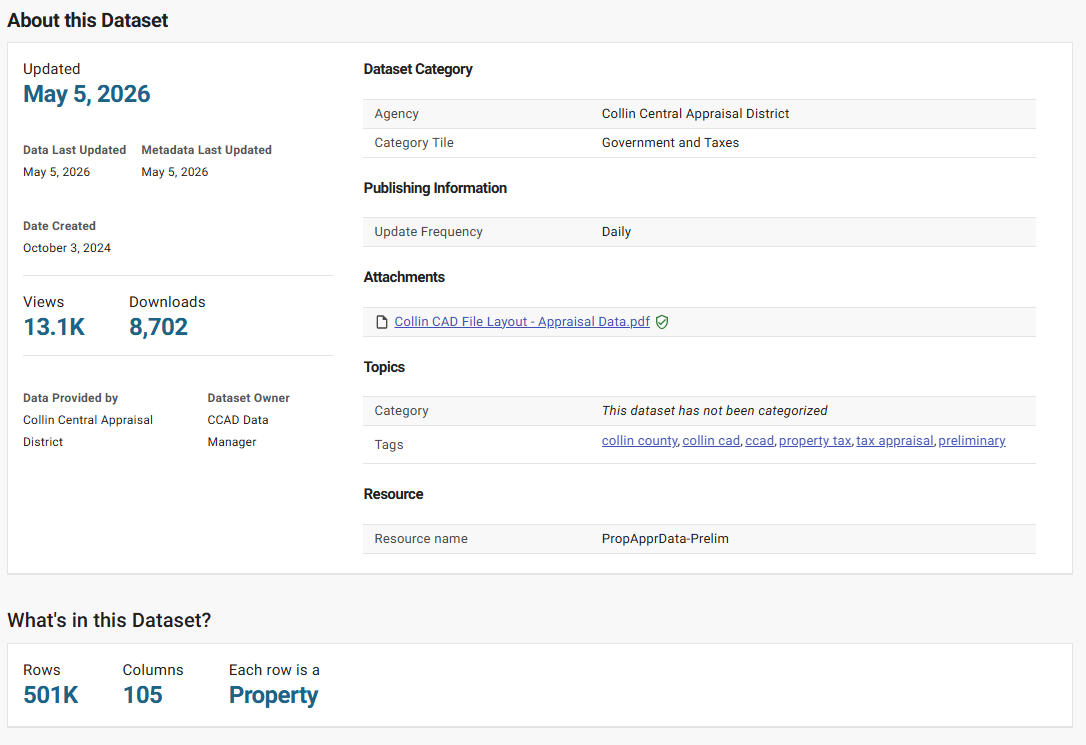

### Getting to the API

On the top right hand of the screen, you will see a dropdown for possible actions, click the dropdown and select "API" to get to the API documentation.  
The API documentation is also available here: https://dev.socrata.com/foundry/data.texas.gov/nne4-8riu

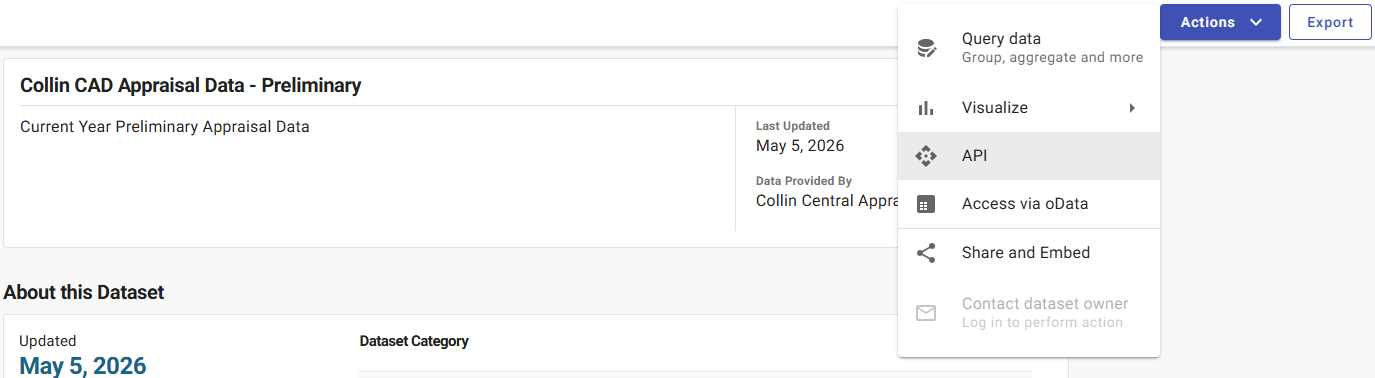

### Using the API to get data

According to the documentation, you should install the sodapy package to interact with the API.  
If you do not have the sodapy package installed already, in a new terminal run: pip install sodapy  
Please do the same for Pandas if that is not already available on your machine.

The documentation states that the API has a 1000 row limit, but it is possible to obtain all records by combining the offset and limit parameters.  
It states to use offset for batch size, and limit for the total number of records to return.

Using these two parameters, we will pull a maximum of 500K total records from the API in 1000 row batches.  
Per the website, no API key is required since this is publicly available.


In [ ]:
#load your packages
import pandas as pd
import numpy as np
from sodapy import Socrata
import datetime as dt


In [ ]:
#connect to API
client = Socrata("data.texas.gov", None)

#All results (limited to 500,000), returned as JSON from API / converted to Python list of dictionaries by sodapy.
results = client.get("nne4-8riu", offset = 1000, limit = 500000)

# Convert to Pandas DataFrame
df = pd.DataFrame.from_records(results)

In [ ]:
#clear API results to free memory
del results

### Cleaning the data

Now that we have our raw data in a DataFrame, we need to do some cleaning before we can start exploring it.  
Make sure you have your column decoder handy so we know which items to remove (link here - https://data.texas.gov/api/views/nne4-8riu/files/8e7ebe84-fbaf-4608-9064-012aeae3efe4?download=true&filename=Collin%20CAD%20File%20Layout%20-%20Appraisal%20Data.pdf).  

Based on our decoder we know we should drop the following columns which show details about the owner.  
Note - this is done in good faith to anonymize the owners and details of their ownership, even though this is not technically considered personally identifiable information.

columns to drop:

- propID
- geoID
- ownerid
- ownername
- ownernameaddtl
- owneraddrline1
- owneraddrline2
- owneraddrcity
- owneraddrstate
- owneraddrcountry
- owneraddrzip
- deednum
- deedtypecd
- deedbook
- deedpage
- deedeffdate
- deedfiledate
- dbaname
- proprefid1
- proprefid2
- gispropid

In [ ]:
# removing columns listed above to anonymize dataset
columns_to_drop = ['propid', 'geoid','ownerid', 'ownername', 'ownernameaddtl', 'owneraddrline1', 'owneraddrline2', 'owneraddrcity', 'owneraddrstate',
'owneraddrcountry', 'owneraddrzip', 'deednum', 'deedtypecd', 'deedbook', 'deedpage', 'deedeffdate', 'deedfiledate', 'dbaname', 'proprefid1', 'proprefid2','gispropid']

df = df.drop(columns = columns_to_drop)

Let's take a quick look at our data!

In [ ]:
df.head()

So far, we removed 18 columns to start and we have 87 remaining.  

After glancing through our dataset we start to notice that certain data points are redundant.  
These either only have a single value or there are columns that describe the same thing.  

Let's go ahead and further remove any redundant or uneeded columns

In [ ]:
redundant_columns = [
    'propyear', # always 2026 since it is for the current year
    'situsconcat', # street names and address numbers are available as clean singular columns already
    'situsconcatshort',  # street names and address numbers are available as clean singular columns already
    'legalabssublot', # specific to each address, not useful for modeling or visualization
    'legaldescription', # removing company names to keep data anonymous
    'currvalyear', # always 2026
    'prevvalyear', # will always be current year - 1 (E.g. 2025 in our case)
]

df = df.drop(columns = redundant_columns)

Let's take a look at our data one more time

In [ ]:
df.head()

Down to 80 columns! We are getting there.  
For our review we are only looking at residential homes, so let's filter the property types to Residential only.  
From there we can drop the property type column since they will only have 1 unique value

In [ ]:
df = df[df['propsubtype'] == 'Residential']
df = df.drop(columns={'propsubtype'})

Let's also remove any columns that only have 1 unique value

In [ ]:
df = df.loc[:, df.nunique() > 1]

We'll add a column for when the house was built and how old it is now.  
From there we will drop the original property create date column

In [ ]:
df['year_built'] = pd.to_datetime(df['propcreatedate']).dt.year.astype('Int64')

df['age_of_property_years'] = dt.datetime.now().year - df['year_built']

df = df.drop(columns={'propcreatedate'})

filter for only real properties, removing mineral rights and so forth

In [ ]:
df = df[df['proptype'] == 'Real']

convert boolean columns to integers, False = 0 and True = 1 

In [ ]:
boolean_cols =  df.select_dtypes('bool').columns
df[boolean_cols] = df[boolean_cols].astype(int)

df['imprvpoolflag'] = df['imprvpoolflag'].fillna(0).astype(int)

Further trim down dataset to columns that are only relevant to EDA and ML for house price prediction

In [ ]:
df = df.drop(columns={'entitycodes','situsbldgnum','propstatus','noticevalimprv',
       'noticevalland', 'noticevalmarket', 'noticevalagloss',
       'noticevalappraised', 'noticevalhscaploss', 'noticevalnhscaploss',
       'noticevalassessed', 'noticedate','situsunit','taxagentid',
       # 'taxagentname', just for fun leaving in to see how many residents use tax agents to dispute taxes
       'protestcode', 'udigroupid', 'udiinterestpct','ecogroupid', 'ecogroupgba', 'ecogroupnra',
       ## dropping data for current year since this shouldnt be available at time of prediction
       'currvalimprv', 'currvalland', 'currvalmarket', 'currvalagloss',
       'currvalhscaploss', 'currvalnhscaploss', 'currvalassessed',
       # dropping cols with 97-99% nulls
       'propusecode', 'marketareacode','situsstreetprefix','landagacres','propsplitfrompid','commoninterestpct','imprvunits',
       #drop column with only 1 unique value we filtered for
       'proptype',
       #drop mapid column that is 1:1 with the neighborhood code
       'mapid',
       # drop entitycitycode which is 1:1 with situscity
       'entitycitycode',
       #drop entitysbcl which has > 99% of values in one of two categories for county line
       'entitysbcl'
       })

Lastly, we want to put our target variable for future data scientists as the first column in the dataframe.  
We also will rearrange the dataframe to make the columns more consistent by aligning similar data points from left to right.  
This practice just helps seperate it and keep everything clear for future users.  

For our target column, we are choosing 'currvalappraised' which is the appraised value the county has assigned to the home.  

Important Note - We are intentionally leaving certain columns in a format that is not entirely preprocessed for a ML model.  
This will allow future data analsysts and scientists to explore the data, showcase potential multicolinarty, further cleaning processes, or use it in general for other purposes like projected property tax amount.



In [ ]:
df = df[[
    #target column
    'currvalappraised',
    # physical location information
    'situsstreetname',
    'situsstreetsuffix', 'situscity','legalabssubname', 'situszip',
    'nbhdcode', 'legalabssubcode','landsizeacres', 'landsizesqft',
    # home age
    'year_built', 'age_of_property_years',
    # prior year appraised value 
    'prevvalappraised',
    # prior year year full appraisal financial info
    'prevvalassessed','prevvalmarket',
    'prevvalimprv', 'prevvalland',  'prevvalagloss',
    'prevvalhscaploss', 'prevvalnhscaploss',
    #property codes
    'legalabssubblock','propcategorycode',
    'entityschoolcode', 'landtypecode', 'landcategorycodes',
    'entitymud', 'entitytif',
    'udipropflag',
    'exempthmstdflag', 'exemptcodes',
    # improvements made to the home since the original build
    'imprvyearbuilt','imprvclasscd', 'imprvmainarea', 'imprvpoolflag', 'imprvcategorycodes',
    'taxagentname'
]]

sort dataframe to put rows with the most nulls at the bottom of the dataframe so it doesn't automatically appear at the top when reading in the dataframe to memory making it visually unappealing

In [ ]:
df = df.loc[df.isna().sum(axis =1).sort_values().index].reset_index(drop = True)

Thats it! We have cleaned our data, removed approximately 100K records which are not relevant to our future review.  
We also reduced the dataset dimension from 105 column to only the 36 necessary columns for data exploration.

## Exporting Data to CSV

Our final step, we are going to write the dataframe to a comma seperated value (csv) file.  
From there we will upload it to Kaggle via the datasets segment of their website.

In [74]:
df.to_csv('collin_county_appraisal_data_2026.csv', index= False)

### project complete!